# 01 - Cloud Field Overview

Time–height pcolormesh of bulk droplet (NW) and ice-crystal (NF) number
concentrations for every meteogram station in the Zarr store.

Layout: **n_stations rows x 2 columns** (left = NW, right = NF).

### Zarr v2 / v3 compatibility notes

The Zarr stores are written with `zarr_format=2` to work around several
incompatibilities between `xarray` (≥ 2025.4) and `zarr-python` 3.x:

| Issue | Symptom | Resolution |
|-------|---------|------------|
| **Codec API mismatch** | `TypeError: Expected a BytesBytesCodec. Got <class 'numcodecs.blosc.Blosc'>` | Force `zarr_format=2` in `to_zarr()` so `numcodecs.Blosc` is accepted as `compressor`. |
| **Unicode string dtype** | `ValueError: No Zarr data type found that matches {'name': '<U14', 'object_codec_id': 'vlen-utf8'}` | Store string coordinates (e.g. `expname`) as fixed-length bytes (`dtype='S'`) instead of Unicode (`dtype='U'`). zarr-python 3.x infers a `vlen-utf8` codec for `<U` arrays but cannot read it back. |
| **Region writes on coords** | `ValueError: variables … must have at least one dimension in common with the region's dimensions` | Abandoned streaming region-writes; build the full dataset lazily, then write in a single pass. |
| **Fill-value round-trip** | `AttributeError: 'Float32' object has no attribute 'value'` on `open_dataset` | Caused by zarr v3 metadata on read; pinning `zarr_format=2` avoids the issue. |

Existing stores created with `<U` dtypes can be patched locally by converting
the `expname` chunk data from `<U14` → `|S14` and updating `.zarray` /
`.zmetadata` (see `docs/logbook.md`, entry 2026-03-04).


TODO:

- [x] add turbulence, vertical wind speed, temperature, humidity, supersaturation, and other meteorological variables as contour lines into the time-height plots
- [ ] optional: check if overlay variables correlate with number/mass concentrations or tendencies (see correlation cell below)



In [21]:
from __future__ import annotations
import sys, os
import platform, socket
from pathlib import Path
from polarcap_runtime import is_server

# check if polarcap_runtime is installed
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
SRC_DIR = REPO_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("system:", platform.system(), platform.release())
print("hostname:", socket.gethostname())
print("is_server:", is_server())


import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.gridspec as gs

from xhistogram.xarray import histogram as xhist
from utilities import (
    load_process_budget_data, get_extpar_data, apply_publication_style
)

CONFIG_YAML = REPO_ROOT / "notebooks" / "config" / "process_budget.yaml"
cfg = load_process_budget_data(REPO_ROOT, config_path=CONFIG_YAML)


system: Darwin 25.3.0
hostname: MacBookPro
is_server: False
Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr


## Configuration

In [14]:


LBB = slice(None, None)  # liquid-bin view for QW
CBB = slice(None, None)  # ice-shell view for QFW


EXP_IDX        = 0
ZLIM_TH_W      = (1e-5, 1e0)
ZLIM_TH_I      = (1e-5, 1e0)
XLIM_PROC      = (-1e1, 1e1)
YLIM_GLOB      = (700, 1750)
LINTHRESH_PROC = 1e-8
LINSCALE_PROC  = 0.5   # symlog linear region scale; smaller = narrower, so "0" label is clear
SYMLOG_MAJOR_NTICKS = 3  # powers of 10 between major ticks; minor ticks fill the rest (N-1 between majors)
SYMLOG_LABEL_MIN_ABS = 1e-8  # hide labels for |x| < this to avoid overlap near origin; only "0" and larger shown
TERRAIN_LIMS   = (100, 1750)
# Per-station window (start_min, end_min) for rate profiles and dashed lines on QW/QFW; one entry per station.
# TIME_FRAMES_ICE_DETECTED = [(2, 17), (5, 22), (12, 32)]  # (start_min, end_min) per station

# Phase windows (same for all stations): colored bands on QW/QFW and plot extent. t0=0 = seeding time.
WINDOW_SPECS_MIN = [
    ("seeding", "Early ice", 2.0, 12.0, "#4C78A8"),
    ("obs_site", "Ice growth", 5.0, 22.0, "#F58518"),
    ("precip_site", "Ice precip.", 14.0, 28.0, "#54A24B"),
]

# Discrete log-spaced colormap for QW/QFW (16 or 32 levels instead of 256)
N_QLEVELS = 5
def _discrete_log_cmap_norm(cmap_name, vmin, vmax, n_levels):
    boundaries = np.logspace(np.log10(vmin), np.log10(vmax), n_levels + 1)
    cmap = mcolors.ListedColormap(plt.get_cmap(cmap_name)(np.linspace(0, 1, n_levels)))
    norm = mcolors.BoundaryNorm(boundaries, n_levels)
    return dict(cmap=cmap, norm=norm)

# {source_var: (output_name, bin_slice, pos_filter, unit_conversion, plot_label, plot_kwargs)}
active_vars = {
    "QW":  ( "QW_bulk",  LBB, True, True, "QW — liquid water mass", _discrete_log_cmap_norm("viridis", ZLIM_TH_W[0], ZLIM_TH_W[1], N_QLEVELS)),
    "QFW": ( "QFW_bulk", CBB, True, True, "QFW — ice + liquid shell mass", _discrete_log_cmap_norm("viridis", ZLIM_TH_I[0], ZLIM_TH_I[1], N_QLEVELS)),
}


In [15]:

from utilities.process_budget_data import load_process_budget_data, stn_label, select_rates_for_range
import numpy as np

CONFIG_YAML = REPO_ROOT / "notebooks" / "config" / "process_budget.yaml"
cfg = load_process_budget_data(REPO_ROOT, config_path=CONFIG_YAML)

zarr_file = "Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr"
cs_run = "_".join(zarr_file.split("_")[1:5])

if is_server():
    data_dir = Path(cfg["paths"]["server_root"]) / "ensemble_output" / cs_run
    extpar_path400 = Path(cfg["paths"]["server_root"]) / "COS_in" / "extPar_Eriswil_50x40.nc"
    extpar_path100 = (
        Path(cfg["paths"]["server_root"]).parent
        / "RUN_ERISWILL_200x160x100"
        / "COS_in"
        / "extPar_Eriswil_200x160.nc"
    )
else:
    data_dir = Path.home() / "data" / "cosmo-specs" / "meteograms" / cs_run
    extpar_path400 = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_50x40.nc"
    extpar_path100 = Path.home() / "data" / "cosmo-specs" / "meteograms" / "extPar_Eriswil_200x160.nc"

zarr_files = [data_dir / zarr_file]
print(f"Available Zarr stores in {data_dir}:")
for z in zarr_files:
    print(f"  {z.name}")

zarr_path = zarr_files[-1]
print(f"\nUsing: {zarr_path.name}")
print(f"ExtPar: {extpar_path400.name}")
print(f"ExtPar: {extpar_path100.name}")

Zarr store: /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254/Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr
Available Zarr stores in /Users/schimmel/data/cosmo-specs/meteograms/cs-eriswil__20260304_110254:
  Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr

Using: Meteogram_cs-eriswil__20260304_110254_nVar136_nMet3_nExp5.zarr
ExtPar: extPar_Eriswil_50x40.nc
ExtPar: extPar_Eriswil_200x160.nc


In [16]:

# position inside cfg["plot_exp_ids"]
SEED_START = np.datetime64(cfg["seed_start"])
ACTIVE_RANGE_KEY = cfg.get("active_range_key", "ALLBB")

day = np.datetime64(SEED_START, "D")
PLOT_START = day + np.timedelta64(12 * 60 + 25, "m")  # 12:25:00
PLOT_END = day + np.timedelta64(13 * 60 + 5, "m")    # 13:05:00


## Load data

In [17]:
ds_zarr = cfg['ds']
print("Sizes:", dict(ds_zarr.sizes))
print("Data vars:", list(ds_zarr.data_vars))

assert "NW" in ds_zarr.data_vars and "NF" in ds_zarr.data_vars, (
    f"Zarr store must contain NW and NF. Found: {list(ds_zarr.data_vars)}"
)

Sizes: {'expname': 5, 'station': 3, 'time': 4033, 'height_level': 20, 'bins': 66, 'height_level2': 21, 'bins_boundaries': 67}
Data vars: ['SUM_CONDNFROD', 'SUM_P_kollqwf', 'SUM_P_BREAN', 'SUM_P_dqfmelt', 'PML', 'SUM_N_deponf', 'SUM_HOMN', 'SUM_kqf', 'NW', 'QV', 'SUM_P_KOLLQFROD', 'SUM_IMMERN', 'SUM_P_dqwmelt', 'SUM_dqfwmelt', 'SUM_N_IMMERN', 'SUM_CONDQWFROD', 'SUM_P_dnfmelt', 'SUM_N_KOLLQFROD_INS', 'SUM_dnwmelt', 'NINP', 'QFS', 'SUM_depoqf', 'SUM_P_deponf', 'SUM_N_kollqwf', 'SUM_N_CONDQFROD', 'QF', 'SUM_CONDQFROD', 'QIA', 'SUM_N_dqfwmelt', 'SUM_N_KOLLNFROD', 'SUM_P_KOLLNFROD_INS', 'SUM_P_KOLLNI', 'SUM_P_CONDQFROD', 'RHO', 'RGRENZ_right', 'SUM_P_KOLLQFROD_INS', 'SUM_dnfmelt', 'SUM_N_KOLLQFROD', 'SUM_CONDN', 'SUM_KOLLNFROD', 'SUM_N_dqffrier', 'PHL', 'SUM_P_dqfwmelt', 'SUM_N_CONDNFROD', 'QWS', 'SUM_P_HOMQ', 'QFA', 'SUM_P_dqffrier', 'SUM_N_KOLLQI', 'SUM_P_kqf', 'SUM_N_HOMN', 'SUM_BREAQ', 'SUM_N_kqwf', 'SUM_N_BREAN', 'SUM_N_KOLLNFRODI', 'SUM_N_CONDN', 'SUM_deponf', 'SUM_kollqwf', 'SUM_P_KOL

In [18]:
EXP_ID = cfg["plot_exp_ids"][EXP_IDX] if EXP_IDX < len(cfg["plot_exp_ids"]) else EXP_IDX

ds_exp = ds_zarr.isel(expname=EXP_ID)
ds_exp = ds_exp.sel(time=slice(PLOT_START, PLOT_END))
rho = ds_exp["RHO"] if "RHO" in ds_exp.data_vars else None

R = cfg["rates_by_exp"][EXP_ID]
Rsel = select_rates_for_range(R, ACTIVE_RANGE_KEY)
rates_Q_liq = Rsel["rates_Q_liq"]
rates_Q_ice = Rsel["rates_Q_ice"]

print(f"Active variables: {[v for v in active_vars]}")
mass_unit = r"g m$^{-3}$" if rho is not None else r"kg kg$^{-1}$"

bulk = {}
for src_name, (out_name, bin_sl, pos_only, uc, lbl, nkw) in active_vars.items():
    data = ds_exp[src_name]
    if "bins" in data.dims:
        data = data.isel(bins=bin_sl).sum(dim="bins")
    if uc and rho is not None and src_name.startswith("Q"):
        data = data * rho * 1e3
        data.attrs["units"] = mass_unit
    if pos_only:
        data = xr.where(data > 0, data, np.nan)
    data.attrs["long_name"] = lbl
    bulk[out_name] = data

bulk = xr.Dataset(bulk)
n_stations = ds_exp.sizes["station"]
station_labels = {int(k): v for k, v in cfg["station_labels"].items()}

exp_raw = ds_zarr.expname.values[EXP_ID]
exp_label = exp_raw.decode() if isinstance(exp_raw, bytes) else str(exp_raw)


def _clip_window(start, end, time_values):
    t0 = np.datetime64(time_values[0])
    t1 = np.datetime64(time_values[-1])
    start = start if start > t0 else t0
    end = end if end < t1 else t1
    return start, end


time_windows = []
for key, label, start_min, end_min, color in WINDOW_SPECS_MIN:
    start = SEED_START + np.timedelta64(int(start_min * 60), "s")
    end = SEED_START + np.timedelta64(int(end_min * 60), "s")
    start, end = _clip_window(start, end, ds_exp.time.values)
    if start < end:
        time_windows.append(
            {"key": key, "label": label, "start": start, "end": end, "color": color}
        )

plot_settings = {spec[0]: {"label": spec[4], **spec[5]} for spec in active_vars.values()}

print(f"Experiment: {exp_label}")
print(f"Stations: {n_stations}")
print(f"Plot range: {PLOT_START} to {PLOT_END}")
print(f"Time windows: {[w['label'] for w in time_windows]}")
print(f"Budget range key: {ACTIVE_RANGE_KEY}")



lat2D4, lon2D4, hsurf4 = get_extpar_data(str(extpar_path400))
lat2D1, lon2D1, hsurf1 = get_extpar_data(str(extpar_path100))
print(f"ExtPar grid 400m: {lat2D4.shape}, height range: {hsurf4.min():.0f}–{hsurf4.max():.0f} m")
print(f"ExtPar grid 100m: {lat2D1.shape}, height range: {hsurf1.min():.0f}–{hsurf1.max():.0f} m")

# Crop both grids to the coordinate bounding box of their intersection (index slices, not coord values).
lon_min = max(float(np.amin(lon2D4)), float(np.amin(lon2D1)))
lon_max = min(float(np.amax(lon2D4)), float(np.amax(lon2D1)))
lat_min = max(float(np.amin(lat2D4)), float(np.amin(lat2D1)))
lat_max = min(float(np.amax(lat2D4)), float(np.amax(lat2D1)))

def _bbox_index_slices(lat2D, lon2D, lat_min, lat_max, lon_min, lon_max):
    in_bbox = (lat2D >= lat_min) & (lat2D <= lat_max) & (lon2D >= lon_min) & (lon2D <= lon_max)
    rows = np.where(np.any(in_bbox, axis=1))[0]
    cols = np.where(np.any(in_bbox, axis=0))[0]
    if rows.size == 0 or cols.size == 0:
        return slice(None), slice(None)
    return slice(int(rows.min()), int(rows.max()) + 1), slice(int(cols.min()), int(cols.max()) + 1)

s4_lat, s4_lon = _bbox_index_slices(lat2D4, lon2D4, lat_min, lat_max, lon_min, lon_max)
s1_lat, s1_lon = _bbox_index_slices(lat2D1, lon2D1, lat_min, lat_max, lon_min, lon_max)
lat2D4, lon2D4, hsurf4 = lat2D4[s4_lat, s4_lon], lon2D4[s4_lat, s4_lon], hsurf4[s4_lat, s4_lon]
lat2D1, lon2D1, hsurf1 = lat2D1[s1_lat, s1_lon], lon2D1[s1_lat, s1_lon], hsurf1[s1_lat, s1_lon]


Active variables: ['QW', 'QFW']
Experiment: 20260304110446
Stations: 3
Plot range: 2023-01-25T12:25 to 2023-01-25T13:05
Time windows: ['Early ice', 'Ice growth', 'Ice precip.']
Budget range key: ALLBB
ExtPar grid 400m: (26, 36), height range: 597–1205 m
ExtPar grid 100m: (146, 186), height range: 523–1402 m


## Quicklook: mass fields and net process-rate profiles

### Time windows and net budget panels

The pcolormeshes show `QW` and `QFW` (`QWF` in the figure label). The stacked bars are time-mean net process-rate profiles for the configurable windows in `WINDOW_SPECS_MIN`. 

In [23]:
from utilities.process_rates import PROCESS_PLOT_ORDER
from utilities.style_profiles import FULL_COL_IN, MAX_H_IN, MM, proc_color
from matplotlib.ticker import FixedLocator, FuncFormatter

apply_publication_style()
PROCESS_ORDER = list(PROCESS_PLOT_ORDER)

if not time_windows:
    raise ValueError("No valid time windows overlap the selected plot range.")


def _y_coord_name(da):
    return "HMLd" if "HMLd" in da.coords else "height_level"


def _height_centers_and_bar_heights(sample_da, bar_fill=0.92):
    height = np.asarray(sample_da.coords["height_level"].values, dtype=float)
    if height.size == 1:
        return height, np.array([20.0])
    edges = np.empty(height.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (height[1:] + height[:-1])
    edges[0] = height[0] - 0.5 * (height[1] - height[0])
    edges[-1] = height[-1] + 0.5 * (height[-1] - height[-2])
    return height, np.diff(edges) * bar_fill


def _merge_rate_dicts(rates_liq, rates_ice):
    merged = {}
    for proc in PROCESS_ORDER:
        da_liq = rates_liq.get(proc)
        da_ice = rates_ice.get(proc)
        if da_liq is None and da_ice is None:
            continue
        if da_liq is None:
            merged[proc] = da_ice
        elif da_ice is None:
            merged[proc] = da_liq
        else:
            merged[proc] = da_liq + da_ice
    return merged


def _time_mean_profiles(rates_dict, station_idx, window):
    profiles = {}
    for proc, da in rates_dict.items():
        sel = da.isel(station=station_idx).sel(time=slice(window["start"], window["end"]))
        if sel.sizes.get("time", 0) == 0:
            continue
        profiles[proc] = np.nan_to_num(sel.mean(dim="time").compute().values.astype(float))
    return profiles


def _stack_extent(profiles):
    if not profiles:
        return 0.0
    arrs = list(profiles.values())
    pos_sum = np.sum([np.clip(arr, 0.0, None) for arr in arrs], axis=0)
    neg_sum = np.sum([np.clip(arr, None, 0.0) for arr in arrs], axis=0)
    return float(max(np.nanmax(pos_sum), np.nanmax(np.abs(neg_sum))))



def _collect_scale_params(rates_dict, station_count, windows, xlim=None, linthresh=None):
    """
    Determine xlim and linthresh for scaling, unless provided by user.

    Parameters
    ----------
    rates_dict : dict
        The process rates dictionary.
    station_count : int
        Number of stations.
    windows : list
        List of time windows (dicts with "start" and "end").
    xlim : float, optional
        If provided by the user, use as x-axis limit.
    linthresh : float, optional
        If provided by the user, use as symmetric log threshold.

    Returns
    -------
    xlim, linthresh
    """
    if xlim is not None and linthresh is not None:
        return xlim, linthresh

    vmax = 0.0
    nonzero = []
    for station_idx in range(station_count):
        for window in windows:
            profiles = _time_mean_profiles(rates_dict, station_idx, window)
            vmax = max(vmax, _stack_extent(profiles))
            for values in profiles.values():
                arr = np.abs(np.asarray(values, dtype=float))
                arr = arr[np.isfinite(arr) & (arr > 0)]
                if arr.size:
                    nonzero.append(arr)
    computed_xlim = 1.05 * vmax if vmax > 0 else 1.0e-12
    if not nonzero:
        computed_linthresh = 1.0e-10
    else:
        all_nonzero = np.concatenate(nonzero)
        computed_linthresh = max(float(np.quantile(all_nonzero, 0.10)), computed_xlim * 1.0e-8, 1.0e-8)

    # Return user-provided or computed values as appropriate
    final_xlim = xlim if xlim is not None else computed_xlim
    final_linthresh = linthresh if linthresh is not None else computed_linthresh
    return final_xlim, final_linthresh


def _plot_net_profiles(ax, rates_dict, station_idx, window, xlim, linthresh, 
                       lw_white=2.25, lw_step=0.75, lw_black=0.35, fill_alpha=0.5):
    sample_da = next(iter(rates_dict.values())).isel(station=station_idx)
    height, _ = _height_centers_and_bar_heights(sample_da)
    profiles = _time_mean_profiles(rates_dict, station_idx, window)
    active = []
    TOP_ORDER_PROCS = ("DROP_COLLISION", "REFREEZING", "IMMERSION_FREEZING")
    draw_order = [p for p in PROCESS_ORDER   if p not in TOP_ORDER_PROCS] + \
                 [p for p in TOP_ORDER_PROCS if p in PROCESS_ORDER]
    for proc in draw_order:
        values = profiles.get(proc)
        if values is None or not np.any(np.abs(values) > 0):
            continue
        active.append(proc)
        zorder = 30 if proc in TOP_ORDER_PROCS else (1 if proc == "CONDENSATION" else 20)
        ax.step(values, height, color="white", linewidth=lw_white, linestyle="-", alpha=0.5, zorder=zorder)
        ax.fill_betweenx(height, 0, values, color=proc_color(proc), alpha=fill_alpha, linewidth=lw_step, step="post", zorder=zorder + 0.05)
        ax.step(values, height, color="black", linewidth=lw_black, linestyle="-", alpha=1.0, zorder=zorder + 0.1)

    _lin = linthresh if linthresh is not None else LINTHRESH_PROC
    ax.set_xscale("symlog", linthresh=_lin, linscale=LINSCALE_PROC, base=10)
    ax.axvline(0.0, color="0.15", linewidth=0.5, zorder=3)
    ax.grid(axis="x", which="major", alpha=0.18, linewidth=0.35)
    ax.grid(axis="x", which="minor", alpha=0.10, linewidth=0.20)
    ax.set_xlim(xlim if xlim is not None else XLIM_PROC)
    return active


def _set_symlog_ticks(ax, xlim, linthresh, n_decades=SYMLOG_MAJOR_NTICKS):
    """Major ticks at 0 and ±10^(n_decades*k); minor at ±10^(n_decades*k+j) for j=1..n_decades-1."""
    lo, hi = float(xlim[0]), float(xlim[1])
    n = int(n_decades)
    major = [0.0]
    for k in range(-12, 5):
        if k % n != 0:
            continue
        for s in (1.0, -1.0):
            t = s * (10.0 ** k)
            if t != 0 and lo <= t <= hi:
                major.append(t)
    minor = []
    for exp in range(-11, 5):
        if exp % n == 0:
            continue
        for s in (1.0, -1.0):
            t = s * (10.0 ** exp)
            if lo <= t <= hi:
                minor.append(t)
    ax.xaxis.set_major_locator(FixedLocator(sorted(set(major))))
    ax.xaxis.set_minor_locator(FixedLocator(sorted(set(minor))))
    min_abs = SYMLOG_LABEL_MIN_ABS 
    def _fmt(x, pos):
        if x == 0:
            return "0"
        if abs(x) < min_abs:
            return ""
        p = int(round(np.log10(abs(x))))
        if p < 0:
            return r"$-10^{\text{-}" + str(abs(p)) + "}$" if x < 0 else r"$10^{\text{-}" + str(abs(p)) + "}$"
        return rf"$-10^{{{p}}}$" if x < 0 else rf"$10^{{{p}}}$"
    ax.xaxis.set_major_formatter(FuncFormatter(_fmt))
    ax.tick_params(axis="x", which="major", length=4.5)
    ax.tick_params(axis="x", which="minor", length=2.25)
    ax.tick_params(axis="x", which="major", labelsize=7)


rates_Q_total = _merge_rate_dicts(rates_Q_liq, rates_Q_ice)
total_xlim, total_linthresh = _collect_scale_params(rates_Q_total, n_stations, time_windows)
liq_xlim, liq_linthresh = XLIM_PROC[1], LINTHRESH_PROC #_collect_scale_params(rates_Q_liq, n_stations, time_windows)
ice_xlim, ice_linthresh = XLIM_PROC[1], LINTHRESH_PROC #_collect_scale_params(rates_Q_ice, n_stations, time_windows)
print(
    f"Signed-log: total xlim={total_xlim:.0e}, liq xlim={liq_xlim:.0e}, ice xlim={ice_xlim:.0e}"
)

Signed-log: total xlim=2e-03, liq xlim=1e+01, ice xlim=1e+01


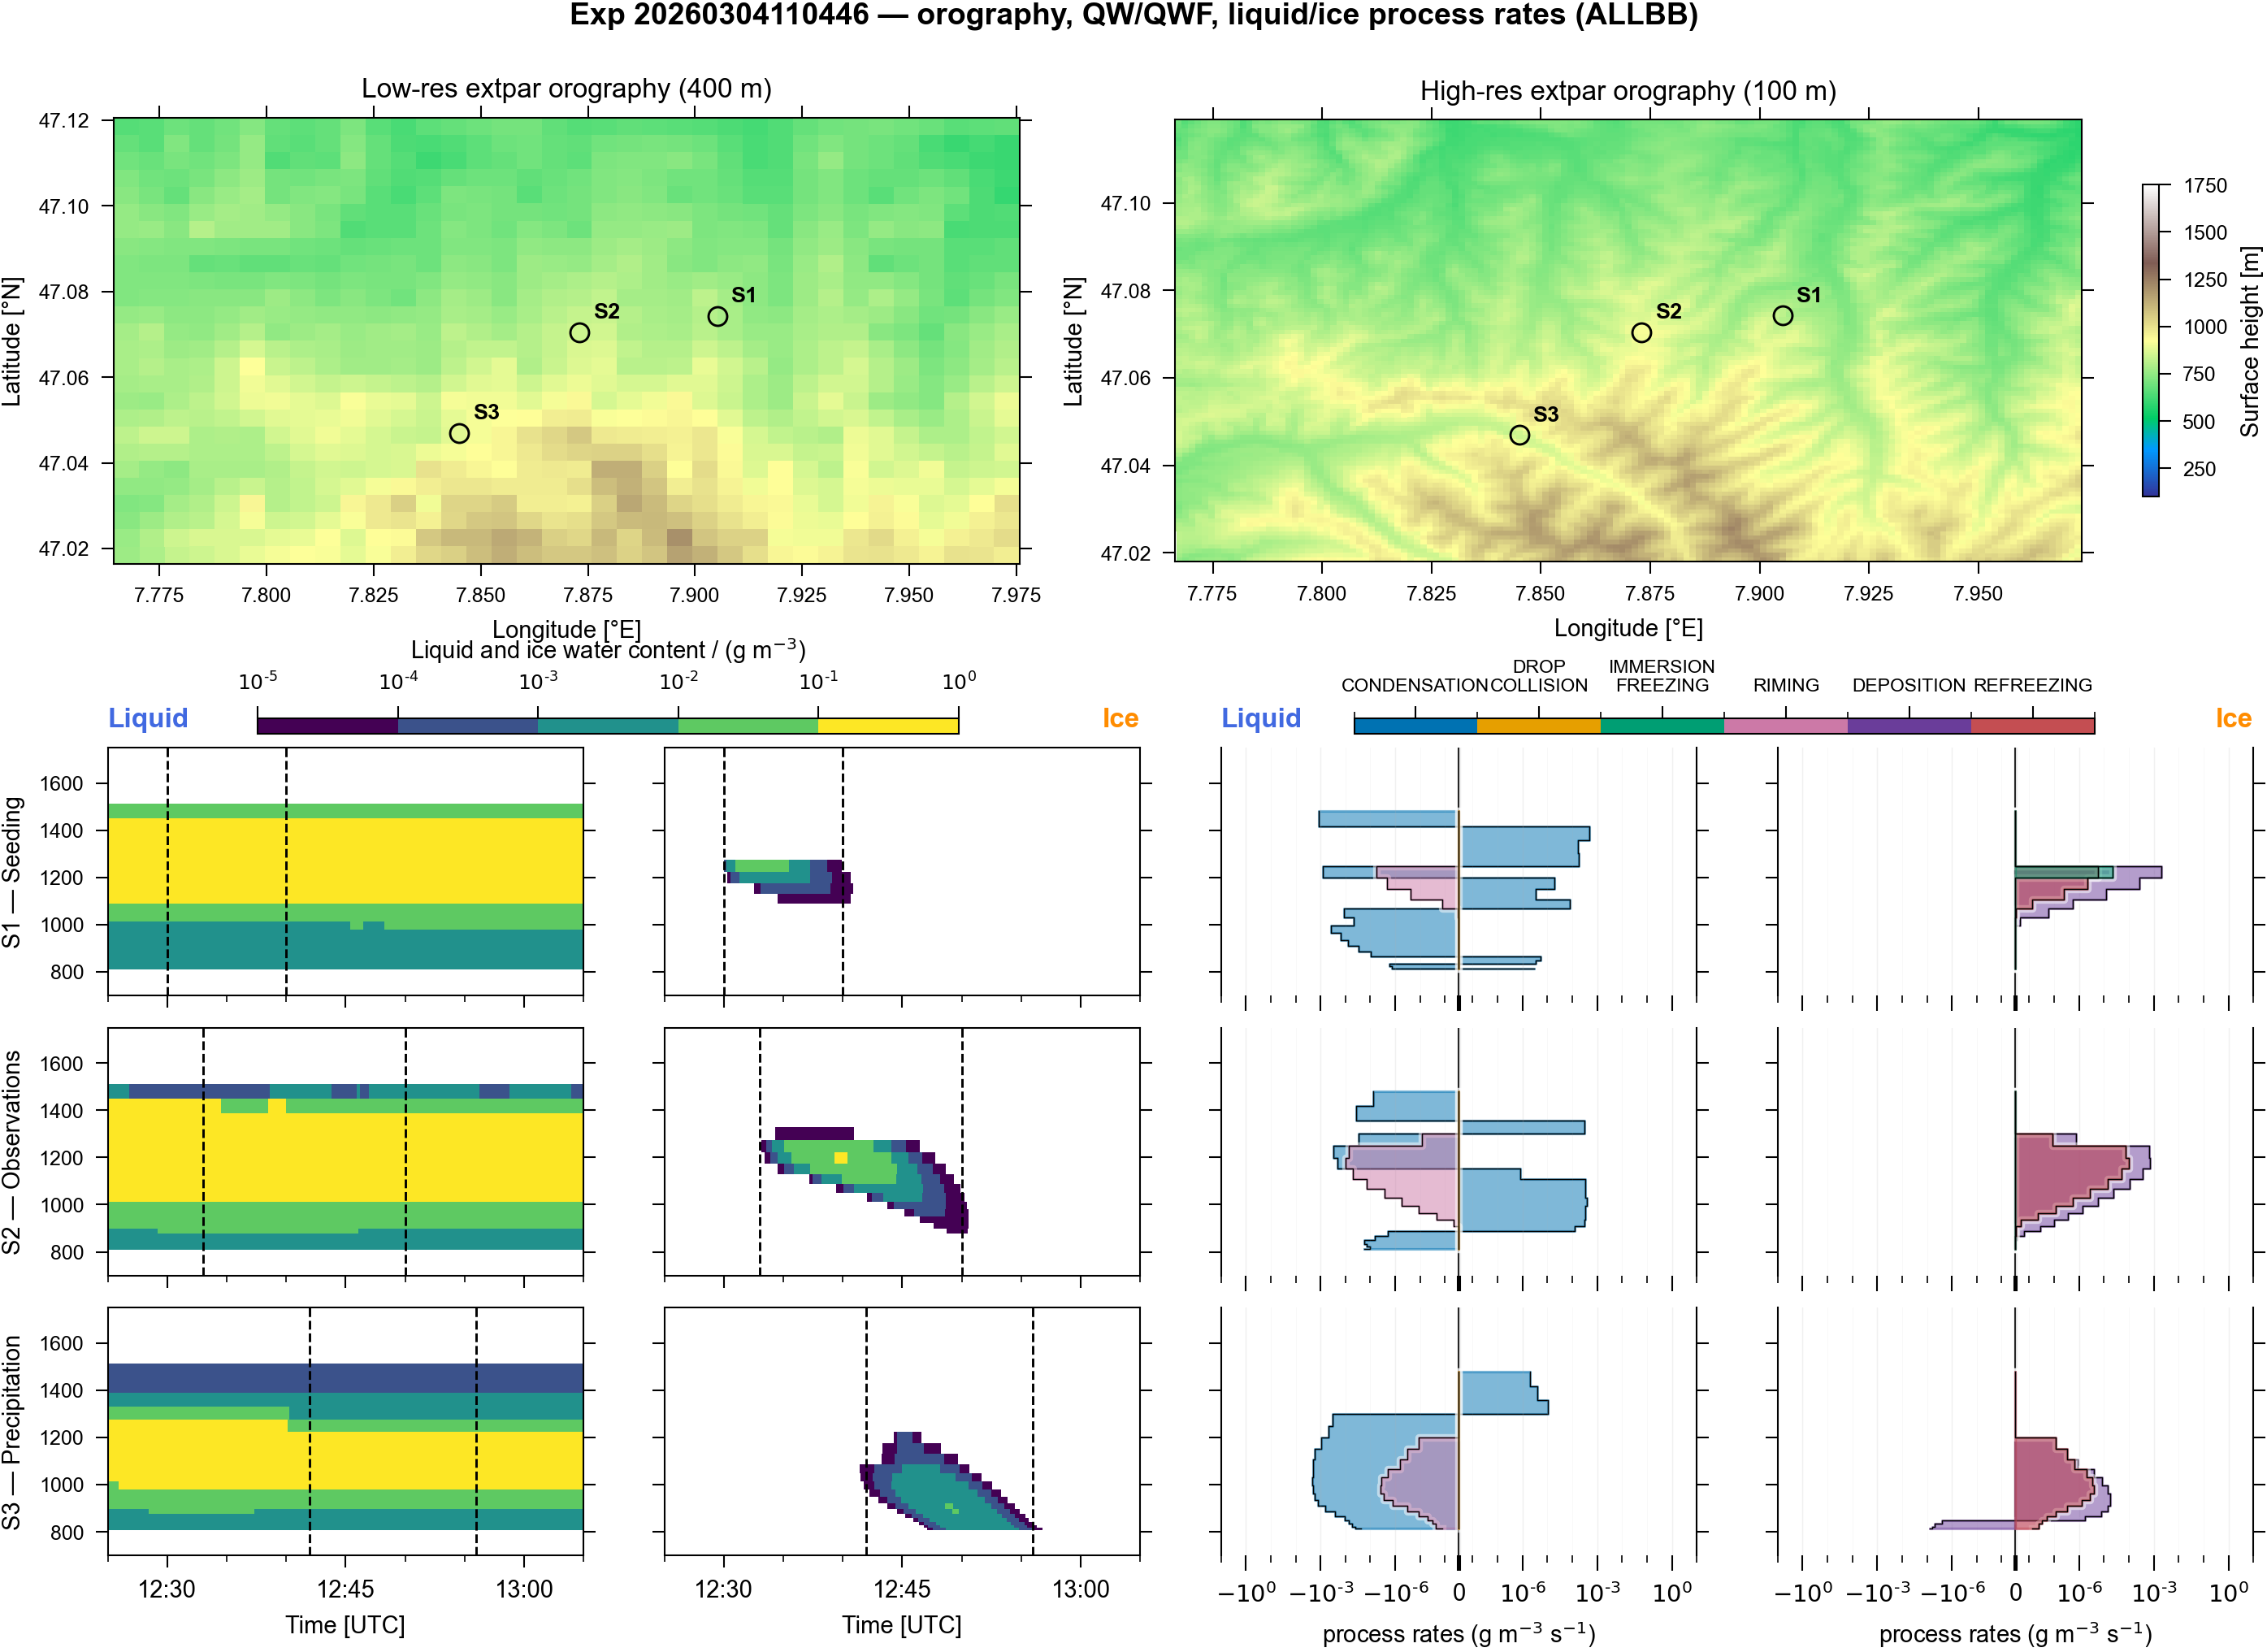

In [28]:


# Layout: maps row 0-1, colorbars row 2, QW/QFW/rates rows 3+
nrows, ncols = 2 + 1 + n_stations, 4
fig_height = min((96 + 25 * n_stations) * MM, MAX_H_IN)
fig = plt.figure(figsize=(FULL_COL_IN * 1.3, fig_height), constrained_layout=True)
width_ratios = [1.0, 1.0, 1.0, 1.0]
grid = gs.GridSpec(
    nrows,
    ncols,
    figure=fig,
    width_ratios=width_ratios,
    height_ratios=[1.3, 1.3, 0.14] + [1.0] * n_stations,
    hspace=0.06,
    wspace=0.1,
)
# Maps: rows 0-1, all 4 cols; each map 2 cols (2x2)
map_grid = grid[:2, :].subgridspec(2, 2, width_ratios=[1, 1], wspace=0.02)
ax_low = fig.add_subplot(map_grid[:, 0])
ax_high = fig.add_subplot(map_grid[:, 1])
# Row 2: horizontal colorbars (QW, QFW, process). Rows 3+: col 0 = QW, col 1 = QFW, col 2 = liquid, col 3 = ice
terrain_vmin = float(min(np.nanmin(hsurf4), np.nanmin(hsurf1))) if TERRAIN_LIMS is None else TERRAIN_LIMS[0]
terrain_vmax = float(max(np.nanmax(hsurf4), np.nanmax(hsurf1))) if TERRAIN_LIMS is None else TERRAIN_LIMS[1]
map_artist = None
for ax, lon, lat, hsurf, title in [
    (ax_low, lon2D4, lat2D4, hsurf4, "Low-res extpar orography (400 m)"),
    (ax_high, lon2D1, lat2D1, hsurf1, "High-res extpar orography (100 m)"),
]:
    map_artist = ax.pcolormesh(
        lon,
        lat,
        hsurf,
        cmap="terrain",
        vmin=terrain_vmin,
        vmax=terrain_vmax,
        shading="auto",
    )
    ax.set_title(title)
    ax.set_xlabel("Longitude [°E]")
    ax.set_ylabel("Latitude [°N]")
    ax.set_aspect("equal")
    for station_idx in range(n_stations):
        slat = float(ds_exp.station_lat.values[station_idx])
        slon = float(ds_exp.station_lon.values[station_idx])
        ax.plot(slon, slat, "o", ms=5.5, mfc="none", mec="black", mew=0.7, zorder=5)
        ax.annotate(
            f"S{station_idx + 1}",
            (slon, slat),
            textcoords="offset points",
            xytext=(4, 4),
            fontsize=6.5,
            fontweight="bold",
        )

fig.colorbar(map_artist, ax=[ax_low, ax_high], label="Surface height [m]", shrink=0.5, pad=0.025)
for ax in (ax_low, ax_high):
    ax.tick_params(top=True, right=True, labeltop=False, labelright=False)

qw_axes, qfw_axes = [], []
budget_axes_top = []
active_processes = set()
last_qw_artist = None
last_qfw_artist = None

for row_idx in range(n_stations):
    ds_stn = bulk.isel(station=row_idx)
    station_name = stn_label(row_idx, station_labels)
    window_stn = time_windows[row_idx]

    ax_qw = fig.add_subplot(grid[row_idx + 3, 0])
    ax_qfw = fig.add_subplot(grid[row_idx + 3, 1], sharey=ax_qw)
    qw_axes.append(ax_qw)
    qfw_axes.append(ax_qfw)

    for ax, name, zlim in [(ax_qw, "QW_bulk", ZLIM_TH_W), (ax_qfw, "QFW_bulk", ZLIM_TH_I)]:
        da = ds_stn[name]
        da = xr.where(da > zlim[0], da, np.nan)
        style = plot_settings[name]
        artist = da.plot.pcolormesh(
            ax=ax,
            x="time",
            y=_y_coord_name(da),
            cmap=style["cmap"],
            norm=style["norm"],
            add_colorbar=False,
            add_labels=False,
            rasterized=True,
        )
        if name == "QW_bulk":
            last_qw_artist = artist
        else:
            last_qfw_artist = artist
        ax.axvline(window_stn["start"], linestyle="--", color="k", linewidth=0.7, zorder=4)
        ax.axvline(window_stn["end"], linestyle="--", color="k", linewidth=0.7, zorder=4)
        ax.set_xlim(PLOT_START, PLOT_END)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
        ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=5))
        
        ax.tick_params(axis="x", top=False, bottom=True, labeltop=False, labelbottom=True, labelsize=7)
        if row_idx < n_stations - 1:
            ax.set_xlabel("")
            ax.set_xticklabels([])
        else:
            ax.set_xlabel("Time [UTC]")
            ax.xaxis.set_label_position("bottom")
        if ax is ax_qw:
            ax.set_ylabel(f"{station_name}")
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)
        ax.tick_params(right=True)
        ax.set_ylim(YLIM_GLOB)

    # Rates: col 2 = liquid, col 3 = ice (per-station window for ice plume)
    for col, rates_dict, xlim, linthresh in [
        (2, rates_Q_liq, (-liq_xlim, liq_xlim), liq_linthresh),
        (3, rates_Q_ice, (-ice_xlim, ice_xlim), ice_linthresh),
    ]:
        ax = fig.add_subplot(grid[row_idx + 3, col], sharey=ax_qw)
        if row_idx == 0:
            budget_axes_top.append(ax)
        active_processes.update(_plot_net_profiles(ax, rates_dict, row_idx, window_stn, xlim, linthresh))
        ax.tick_params(axis="y", labelleft=False, right=True)
        for s in ("top", "bottom"):
            ax.spines[s].set_visible(False)
        if row_idx < n_stations - 1:
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.set_xlabel("process rates " + r"(g m$^{-3}$ s$^{-1}$)")
        _set_symlog_ticks(ax, xlim, linthresh)
        ax.set_ylim(YLIM_GLOB)


# Row 2: horizontal colorbars below maps, above QW/QFW/rates
cax_qw = fig.add_subplot(grid[2, :2])
cax_proc = fig.add_subplot(grid[2, 2:4])
if last_qw_artist is not None:
    fig.colorbar(last_qw_artist, cax=cax_qw, orientation="horizontal", label=r'Liquid and ice water content / (g m$^{-3}$)')

def _log_cbar_fmt(x, pos):
    """Same power-of-10 style as rates xticklabels (short dash in exponent)."""
    if x <= 0:
        return ""
    p = int(round(np.log10(x)))
    if p < 0:
        return r"$10^{\text{-}" + str(abs(p)) + "}$"
    return rf"$10^{{{p}}}$"
for cax in (cax_qw,):
    cax.xaxis.set_major_formatter(FuncFormatter(_log_cbar_fmt))
    cax.xaxis.set_ticks_position("top")
    cax.xaxis.set_label_position("top")
    cax.tick_params(axis="x", top=True, bottom=False, labeltop=True, labelbottom=False)
    
qw_axes[0].set_title('Liquid', color='royalblue', ha='left', x=0.0, weight='bold')
qfw_axes[0].set_title('Ice',    color='darkorange', ha='right', x=1.0, weight='bold')
budget_axes_top[0].set_title('Liquid', color='royalblue', ha='left', x=0.0, weight='bold')
budget_axes_top[1].set_title('Ice',    color='darkorange', ha='right', x=1.0, weight='bold')

legend_order = [p for p in PROCESS_ORDER if p in active_processes]
if legend_order:
    proc_cmap = mcolors.ListedColormap([proc_color(p) for p in legend_order], name="proc")
    proc_norm = mcolors.BoundaryNorm(np.arange(len(legend_order) + 1), proc_cmap.N)
    sm = plt.cm.ScalarMappable(norm=proc_norm, cmap=proc_cmap)
    sm.set_array([])
    cbar_proc = fig.colorbar(sm, cax=cax_proc, orientation="horizontal", ticks=np.arange(len(legend_order)) + 0.5)
    cbar_proc.ax.set_xticklabels([p.replace("_", "\n") for p in legend_order], fontsize=5.5)
    cbar_proc.ax.xaxis.set_ticks_position("top")
    cbar_proc.ax.xaxis.set_label_position("top")
    cbar_proc.outline.set_linewidth(0.5)

fig.canvas.draw()
for cax in (cax_qw, cax_proc):
    b = cax.get_position()
    w_new = b.width * 0.7
    cax.set_position([b.x0 + (b.width - w_new) / 2, b.y0, w_new, b.height/2])


fig.suptitle(
    f"Exp {exp_label} — orography, QW/QWF, liquid/ice process rates ({ACTIVE_RANGE_KEY})",
    y=1.01,
)
os.makedirs("output/gfx/png/01", exist_ok=True)
fig.savefig(
    f"output/gfx/png/01/cloud_field_overview_mass_profiles_steps_symlog_{exp_label}_{ACTIVE_RANGE_KEY}.png", dpi=300, bbox_inches="tight",
)
plt.show()